## 1. Get data

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, dowload it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory already exists ... skipping dowload")
else:
  print(f"{image_path} does not exist, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

# Dowload pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print(f"Downloading pizza, steak and sushi data... ")
  f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unziping pizza, steak, sushi data...")
  zip_ref.extractall(image_path)

data\pizza_steak_sushi directory already exists ... skipping dowload
Unziping pizza, steak, sushi data...


In [3]:
import os
def walk_through_dir(dir_path):
  """"Walks through dir_path returning its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [4]:
#Setup train and test path
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 1.1 Plot Data

data\pizza_steak_sushi\train\sushi\148799.jpg
sushi
Random image path: data\pizza_steak_sushi\train\sushi\148799.jpg
image class: sushi
Image size: (384, 512)
Image mode: RGB


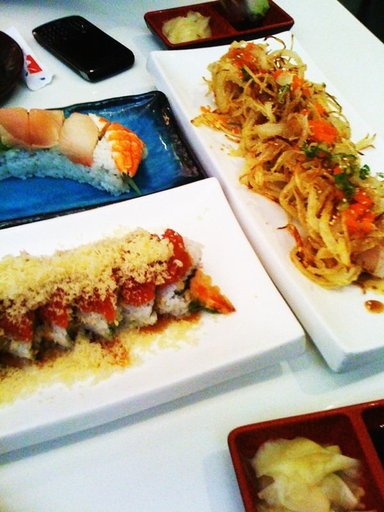

In [5]:
#Plot one of the images
from PIL import Image
import matplotlib.pyplot as plt
import random

# Set seed
random.seed(42)

# Get all image paths
image_paths = list(train_dir.glob("*/*.jpg"))

# Get random image path
random_image_path = random.choice(image_paths)
print(random_image_path)

# Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

# Open image
img = Image.open(random_image_path)

# Print metadata
print(f"Random image path: {random_image_path}")
print(f"image class: {image_class}")
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")


img

(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

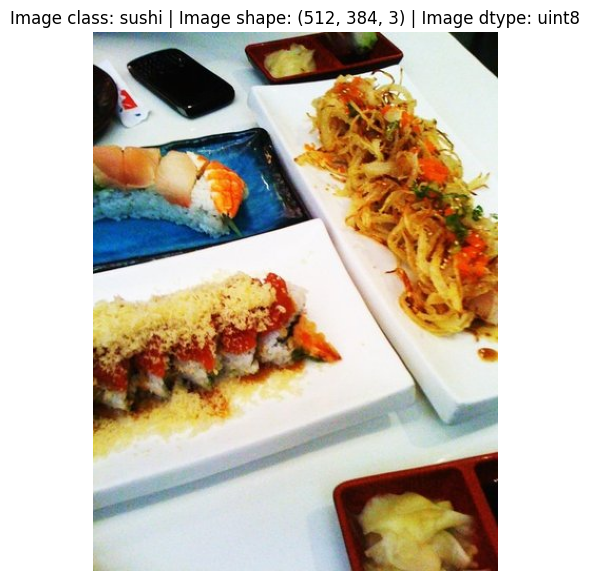

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Turn image into array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} | Image dtype: {img_as_array.dtype}")
plt.axis(False)

## 2. Transform data



In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms # Correct the import statement

In [8]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our image to 64x64
    transforms.Resize(size=(64,64)),
    # Flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn our image into a torch.Tensor
    transforms.ToTensor()
    ])


In [9]:
print(torch.cuda.is_available())


True


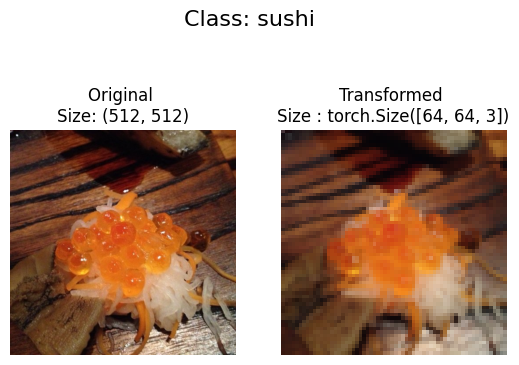

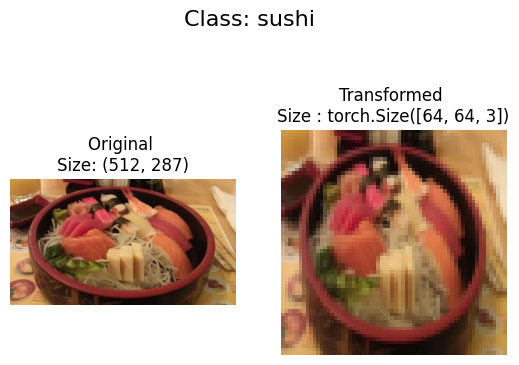

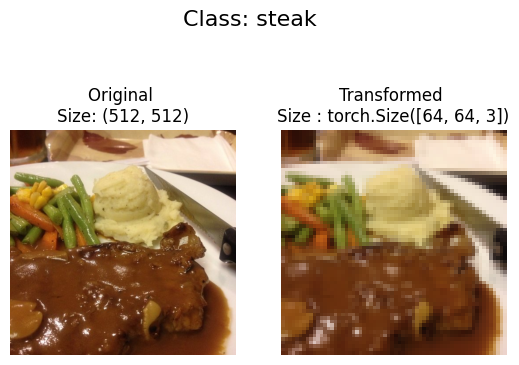

In [10]:
def plot_transformed_images(image_paths:list, transform, n=3, seed=None):
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize: {f.size}")
      ax[0].axis("off")


      # Transform and plot image
      # Note: Permute() will change shape of image to suit matplotlib
      # Ppytorch default is (C,H,H) but plt is (H,H,C)
      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize : {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_paths,
                        transform=data_transform,
                        n=3)

### 2.1 Load image data using ImageFolder

In [11]:
#Use ImageFolder to creat dataset
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, #a transform for the data 
                                  target_transform=None) # a transform for the label/taret

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [12]:
class_name = train_data.classes
class_name

['pizza', 'steak', 'sushi']

In [13]:
class_index = train_data.class_to_idx
class_index

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [14]:
len(train_data), len(test_data)

(225, 75)

In [15]:
img, label = train_data[0][0], train_data[0][1]

print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [C - H - W]
Image permute: torch.Size([64, 64, 3]) -> [H - W - C]


Text(0.5, 1.0, 'pizza')

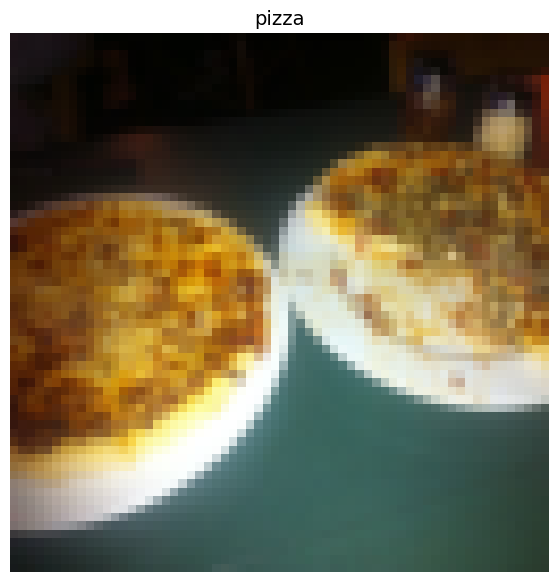

In [16]:
#rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

#print out different shapes
print(f"Original shape: {img.shape} -> [C - H - W]")
print(f"Image permute: {img_permute.shape} -> [H - W - C]")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_name[label], fontsize=14)

## 3. Turn loaded images into 'dataloaders'

In [17]:
# Creat dadtaloaders
from torch.utils.data import dataloader
BATCH_SIZE=1    
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x20dbb120350>,
 <torch.utils.data.dataloader.DataLoader at 0x20dbb2c2690>)

In [18]:
len(train_dataloader), len(test_dataloader)

(225, 75)

### 3.1 Loading image data with a custom dataset(Not with imagefolder)

In [19]:
import os
import pathlib
from PIL import Image
from torch.utils.data import dataset
from torchvision import transforms
from typing import Tuple, Dict, List



In [20]:
# Setup path for target directory
target_directory = train_dir
print(f"Target_dir: {target_directory}")

# Get class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target_dir: data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [21]:
def find_classes(directory: str):
    """Finds the class folder name in a target directory"""
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f"Counldn't find any classes in {directory}... please check file structure.")
    
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [22]:
from torch.utils.data import Dataset

# Creat a class
class ImageFolderCustom(Dataset):
    #Initialize our custom dataset
    def __init__(self,
                 targ_dir: str,
                 transform=None):
        # Creat class atributes
        #Get all the image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        #Setup transform
        self.transform = transform

        #Creat classes and class_indx
        self.classes, self.class_to_idx = find_classes(targ_dir)
        

    # Creat a function to load images
    def load_images(self, index: int) -> Image.Image:
        """Opens an image via a path and returns it."""
        image_path = self.paths[index]
        return Image.open(image_path)
    

    # Overwrite len()
    def __len__(self) -> int:
        """Returns the total number of samples."""
        return len(self.paths)
    
    # Overwrite getitem method
    def __getitem__(self, index: int)-> Tuple[torch.Tensor, int]:
        """Return one sample of data, data and label"""
        img = self.load_images(index)
        class_name = self.paths[index].parent.name # expects path in format data_folder/class_name/image.jpg
        class_idx = self.class_to_idx[class_name]

    # Transform if nescessary
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx



In [23]:
train_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.ToTensor()
                                      ])

test_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                     transforms.ToTensor()])

In [24]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transform)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transform)

In [25]:
len(train_data), len(train_data_custom)


(225, 225)

In [26]:
len(test_data), len(test_data_custom)

(75, 75)

In [27]:
train_data_custom.classes, test_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 3.2 Creat a function to display random images


In [28]:
import torch.utils.data.dataset


def display_rand_img(data_set: torch.utils.data.Dataset,
                     classes: List[str] = None,
                     n: int = 10,
                     display_shape: bool = True,
                     seed: int = None):
    # Adjsut display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display, purpose, n shouldn't be larger then 10, setting to 10 and removing shape display.")
    
    # set seed
    if seed:
        random.seed(seed)
    
    # Get random sample index
    random_sample_idx = random.sample(range(len(data_set)), k= n)

    # Set plot
    plt.figure(figsize=(16, 8))

    # Loop through random idx
    for i, targ_sample in enumerate(random_sample_idx):
        targ_img, targ_label = data_set[targ_sample][0], data_set[targ_sample][1]

        # Adjust dimensions 
        targ_img_adjust = targ_img.permute(1,2,0) # [c - H - W] -> [H - W - C]

        # Plot imgs
        plt.subplot(1, n, i+1)
        plt.imshow(targ_img_adjust)
        plt.axis("off")
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape:\n {targ_img_adjust.shape}"
        if n <= 5:
            plt.title(title,fontsize=16)
        else:
            plt.title(title,fontsize=8)


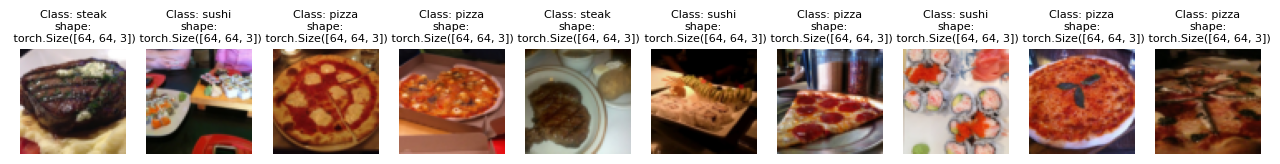

In [29]:
# Display rand images
display_rand_img(train_data,
                 n=10,
                 classes=class_name,
                 seed=None)

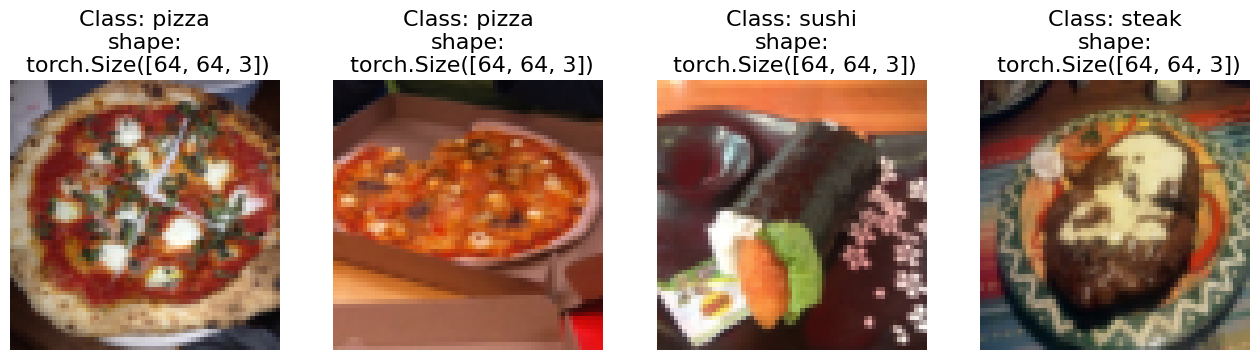

In [30]:
# Display custom dataset 
display_rand_img(train_data_custom,
                 n=4,
                 classes=class_name,
                 seed=None)

## 4. Creat a data loader with custom dataset 

In [31]:
# Creat dataloaders 
from torch.utils.data import dataloader
import os
BATCH_SIZE= 32
#num_workers = os.cpu_count()
train_custom_dataloader = DataLoader(train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=0,
                                     shuffle=True)

test_custom_dataloader = DataLoader(test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=0,
                                    shuffle=False)
train_custom_dataloader, test_custom_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x20dbb795f70>,
 <torch.utils.data.dataloader.DataLoader at 0x20dbb49bcb0>)

In [32]:
img_custom, label_custom = next(iter(train_custom_dataloader))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

### 4.1 Data augmentation

In [33]:
from torchvision.transforms import v2
train_transform = v2.Compose([v2.Resize(size=(224, 224)),
                             v2.TrivialAugmentWide(num_magnitude_bins=31),
                             v2.ToTensor()
])

test_transform = v2.Compose([v2.Resize(size=(224, 224)),
                            v2.ToTensor()])

c:\Users\didio\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [34]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

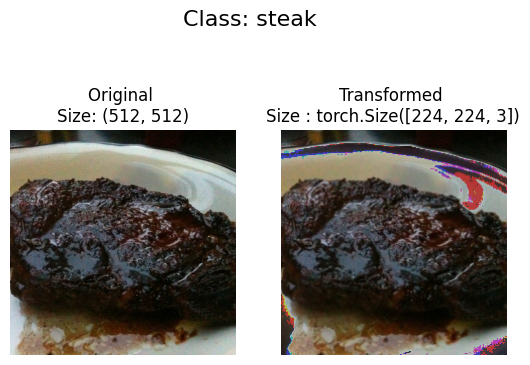

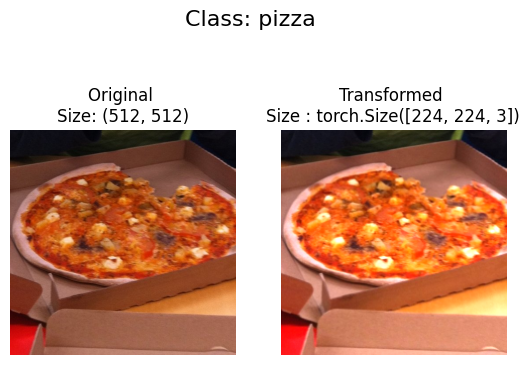

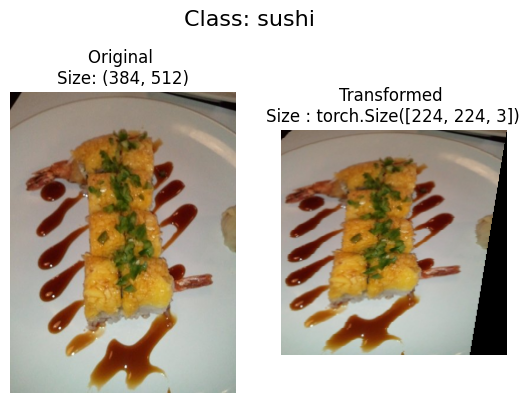

In [35]:
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transform,
                        n=3,
                        seed=None
)

## 5.0 Model0: Baseline model (without data augmentation)


In [36]:
# Creat a transform
from torchvision.transforms import v2
Stransform = v2.Compose([v2.Resize(size=(64, 64)),
                        v2.ToTensor()])

### 5.1 Creat dataloader 


In [37]:
# Load data
from torchvision import datasets

Strain_dataset = datasets.ImageFolder(root=train_dir,
                                      transform=Stransform,
                                      )

Stest_dataset = datasets.ImageFolder(root=test_dir,
                                     transform=Stransform)

# Turn dataset into dataloader
from torch.utils.data import DataLoader
import os 

BATCH_SIZE = 32
num_of_workers = os.cpu_count()

Strain_dataloader = DataLoader(dataset=Strain_dataset,
                               batch_size=BATCH_SIZE,
                               num_workers=0,
                               shuffle=True)

Stest_dataloader = DataLoader(dataset=Stest_dataset,
                              batch_size=BATCH_SIZE,
                              num_workers=0,
                              shuffle=False)


In [38]:
# Set up device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

### 5.2 Creat NN

In [114]:
import torch
from torch import nn

class TinyVGG(nn.Module):
    """
    A TinyVGG model with three convolutional blocks, BatchNorm, and Dropout.
    Suitable for small image classification tasks.
    """
    def __init__(self, 
                 input_shape: int,      # Number of input channels (e.g., 3 for RGB)
                 output_shape: int,
                 hidden_units: int = 10 # Number of filters in conv layers
                ):
        super().__init__()
        
        # First convolutional block
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        
        # Second convolutional block
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        
        # Classifier (flatten and fully connected layer)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16, len(class_name))  # Adjust 4*4 if your input image size is different
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        #print(x)
        x = self.block2(x)
        #print(x)
        x = self.classifier(x)
        #print(x)
        return x

In [115]:
import torch
from torch import nn
torch.manual_seed(42)
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_name)).to(device)
model_0


TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

### 5.3 Try forward pass

In [116]:
image_batch, label_batch = next(iter(Strain_dataloader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [117]:
model_0(image_batch.to(device))

tensor([[0.0578, 0.0634, 0.0351],
        [0.0657, 0.0650, 0.0398],
        [0.0702, 0.0678, 0.0412],
        [0.0687, 0.0646, 0.0417],
        [0.0625, 0.0613, 0.0355],
        [0.0587, 0.0595, 0.0358],
        [0.0634, 0.0637, 0.0376],
        [0.0653, 0.0615, 0.0376],
        [0.0678, 0.0621, 0.0349],
        [0.0620, 0.0599, 0.0371],
        [0.0607, 0.0628, 0.0387],
        [0.0638, 0.0589, 0.0352],
        [0.0658, 0.0611, 0.0369],
        [0.0703, 0.0689, 0.0330],
        [0.0557, 0.0571, 0.0356],
        [0.0632, 0.0642, 0.0388],
        [0.0639, 0.0616, 0.0375],
        [0.0605, 0.0600, 0.0374],
        [0.0623, 0.0627, 0.0368],
        [0.0740, 0.0676, 0.0400],
        [0.0621, 0.0613, 0.0361],
        [0.0632, 0.0599, 0.0366],
        [0.0662, 0.0627, 0.0334],
        [0.0637, 0.0622, 0.0394],
        [0.0670, 0.0666, 0.0363],
        [0.0650, 0.0601, 0.0405],
        [0.0639, 0.0597, 0.0395],
        [0.0733, 0.0687, 0.0412],
        [0.0697, 0.0631, 0.0402],
        [0.062

In [56]:
10*16*16

2560

### 5.4 Try torchinfo


In [57]:
from torchinfo import summary
summary(model=model_0,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [58]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)

In [59]:
def train_step(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(data_loader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(data_loader)
    train_acc = train_acc / len(data_loader)
    return train_loss, train_acc

In [60]:
def test_step(model: torch.nn.Module, 
              data_loader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(data_loader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(data_loader)
    test_acc = test_acc / len(data_loader)
    return test_loss, test_acc

### 5.5 Creat train func

In [163]:
from tqdm.auto import tqdm
from helper_functions import *


# Creat func that takes varius parameters
def train(model: torch.nn.Module,
          train_dataloader,
          test_dataloader,
          optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):
    
    # Creat results dict
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    # Start looping through epochs
    for epoch in tqdm(range(epochs)):

        # Call train function
        train_loss, train_acc = train_step(model=model,
                data_loader=train_dataloader,
                loss_fn=loss_fn,
                optimizer=optimizer,)
        
        # Call test function
        test_loss, test_acc = test_step(model=model,
                data_loader=test_dataloader,
                loss_fn=loss_fn,)
        
                
        results["test_acc"].append(test_acc)
        results["test_loss"].append(test_loss)
        results["train_acc"].append(train_acc)              
        results["train_loss"].append(train_loss)


        if epoch % 5 == 0 or epoch==epochs - 1:
            print(f"\nEpoch {epoch}\n----------")
            print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
                  f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    
    return results

### 5.6 Train Model 0

In [100]:

torch.cuda.manual_seed(42)
torch.manual_seed(42)

EPOCHS = 5


model_0_result = train(model=model_0,
                       train_dataloader=Strain_dataloader,
                       test_dataloader=Stest_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1
----------


 40%|████      | 2/5 [00:01<00:02,  1.35it/s]

Epoch: 1 | Train loss: 1.0906 | Train acc: 0.3398 | Test loss: 1.0977 | Test acc: 0.3125
Epoch 2
----------


 60%|██████    | 3/5 [00:02<00:02,  1.02s/it]

Epoch: 2 | Train loss: 1.0442 | Train acc: 0.4766 | Test loss: 1.1008 | Test acc: 0.2708
Epoch 3
----------


 80%|████████  | 4/5 [00:04<00:01,  1.17s/it]

Epoch: 3 | Train loss: 1.0166 | Train acc: 0.5039 | Test loss: 1.1017 | Test acc: 0.2917
Epoch 4
----------


100%|██████████| 5/5 [00:05<00:00,  1.13s/it]

Epoch: 4 | Train loss: 1.0147 | Train acc: 0.4961 | Test loss: 1.0975 | Test acc: 0.2812


### 5.7 Plot model

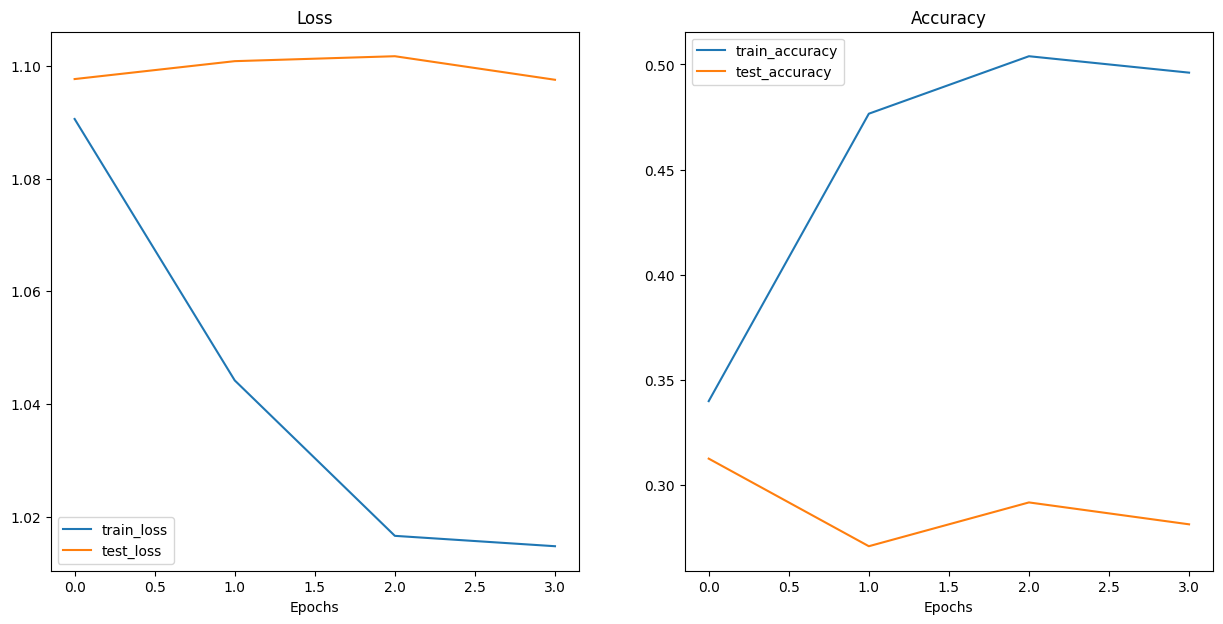

In [101]:
from helper_functions import plot_loss_curves

plot_loss_curves(model_0_result)

## 6.0 Craet Model 1

In [128]:
import torch
from torch import nn

class TinyVGG_1(nn.Module):
    """
    A TinyVGG model with three convolutional blocks, BatchNorm, and Dropout.
    Suitable for small image classification tasks.
    """
    def __init__(self, 
                 input_shape: int,      # Number of input channels (e.g., 3 for RGB)
                 output_shape: int,
                 hidden_units: int = 64 # Number of filters in conv layers
                ):
        super().__init__()
        
        # First convolutional block
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # Second convolutional block
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # Third convolutional block
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # Classifier (flatten and fully connected layer)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 8 * 8, len(class_name))  # Adjust 4*4 if your input image size is different
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        #print(x)
        x = self.block2(x)
        #print(x)
        x = self.block3(x)
        #print(x)
        x = self.classifier(x)
        #print(x)
        return x

In [129]:
import torch
from torch import nn

torch.manual_seed(42)
model_1 = TinyVGG_1(input_shape=3,
                    hidden_units=10,
                    output_shape=len(class_name)).to(device)
model_1

TinyVGG_1(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dr

In [130]:
model_1(image_batch.to(device))

tensor([[ 1.7250e+00,  1.3843e+00,  1.0870e+00],
        [ 1.0753e+00,  6.1631e-01, -1.0641e+00],
        [ 4.1619e-01,  5.2448e-01,  5.1931e-01],
        [ 8.6124e-01,  8.2845e-01,  5.2657e-01],
        [ 1.3778e+00,  6.4689e-01,  1.3148e-03],
        [ 1.2761e+00,  6.7706e-01,  7.1421e-01],
        [ 1.3930e+00,  7.9000e-01,  1.2551e+00],
        [ 1.8627e+00,  7.8564e-01,  1.1779e+00],
        [ 6.7411e-01,  5.3998e-01, -5.9887e-02],
        [ 1.5953e+00,  5.4063e-01,  9.9080e-01],
        [ 1.3701e+00, -9.7998e-02,  6.8449e-01],
        [ 7.6851e-02,  3.5349e-02,  6.8222e-01],
        [ 1.8627e+00,  9.3394e-01,  7.3059e-01],
        [ 1.4512e+00, -5.9858e-01,  5.6117e-01],
        [ 1.4807e+00, -4.2776e-01,  1.1069e+00],
        [ 3.4447e-01,  9.2149e-01,  5.3319e-01],
        [ 1.2510e+00,  7.8079e-01,  7.9139e-01],
        [ 1.5199e+00,  2.1856e-01, -6.6292e-02],
        [ 1.2734e+00,  9.6513e-01,  1.0517e+00],
        [ 1.2018e+00, -5.4412e-03,  3.8630e-01],
        [ 7.9863e-01

In [131]:
# Create training transform with TrivialAugment
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor() 
])

# Create testing transform (no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


In [132]:
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [133]:
# Turn Datasets into DataLoader's
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented, 
                                        batch_size=BATCH_SIZE, 
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x20dbb3a43b0>,
 <torch.utils.data.dataloader.DataLoader at 0x20dbb3a7fe0>)

In [134]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)

In [136]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 10

model_1_result = train(model=model_1,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_simple,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1
----------


 20%|██        | 2/10 [00:22<01:30, 11.35s/it]

Epoch: 1 | Train loss: 1.1692 | Train acc: 0.4219 | Test loss: 1.1419 | Test acc: 0.3201
Epoch 2
----------


 30%|███       | 3/10 [00:44<01:50, 15.83s/it]

...

Epoch: 7 | Train loss: 1.2631 | Train acc: 0.2930 | Test loss: 1.1427 | Test acc: 0.2689
Epoch 8
----------


 90%|█████████ | 9/10 [02:36<00:18, 18.87s/it]

Epoch: 8 | Train loss: 1.2319 | Train acc: 0.3672 | Test loss: 1.1293 | Test acc: 0.3409
Epoch 9
----------


100%|██████████| 10/10 [03:00<00:00, 18.02s/it]

Epoch: 9 | Train loss: 1.1836 | Train acc: 0.4062 | Test loss: 1.1382 | Test acc: 0.2794


(None, None)

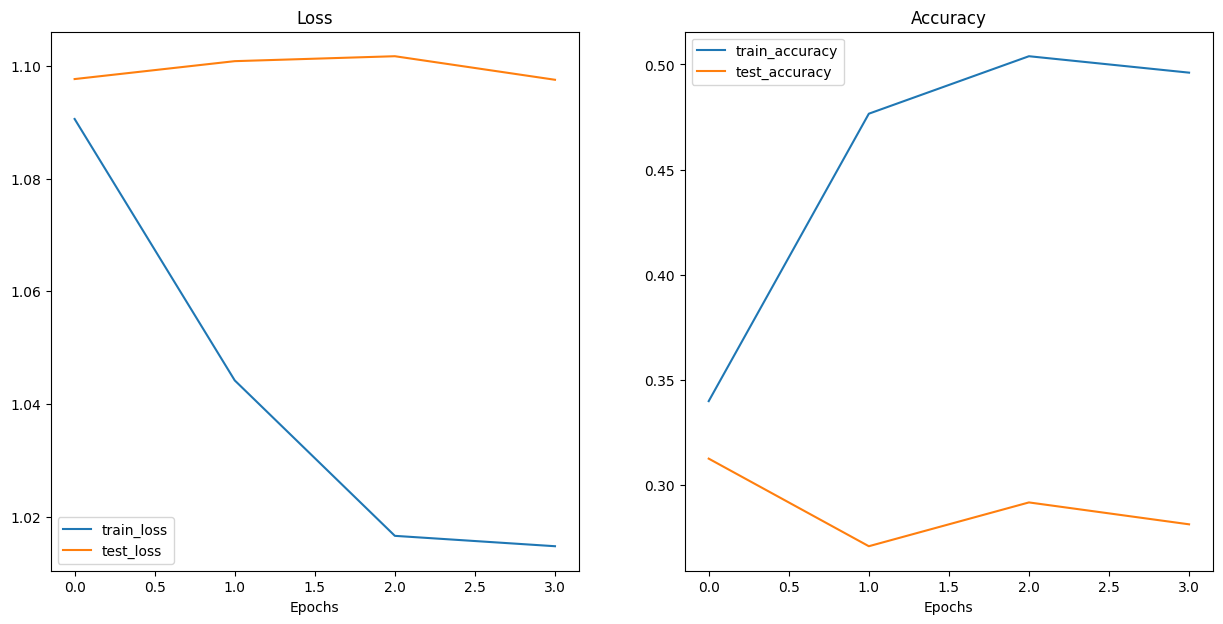

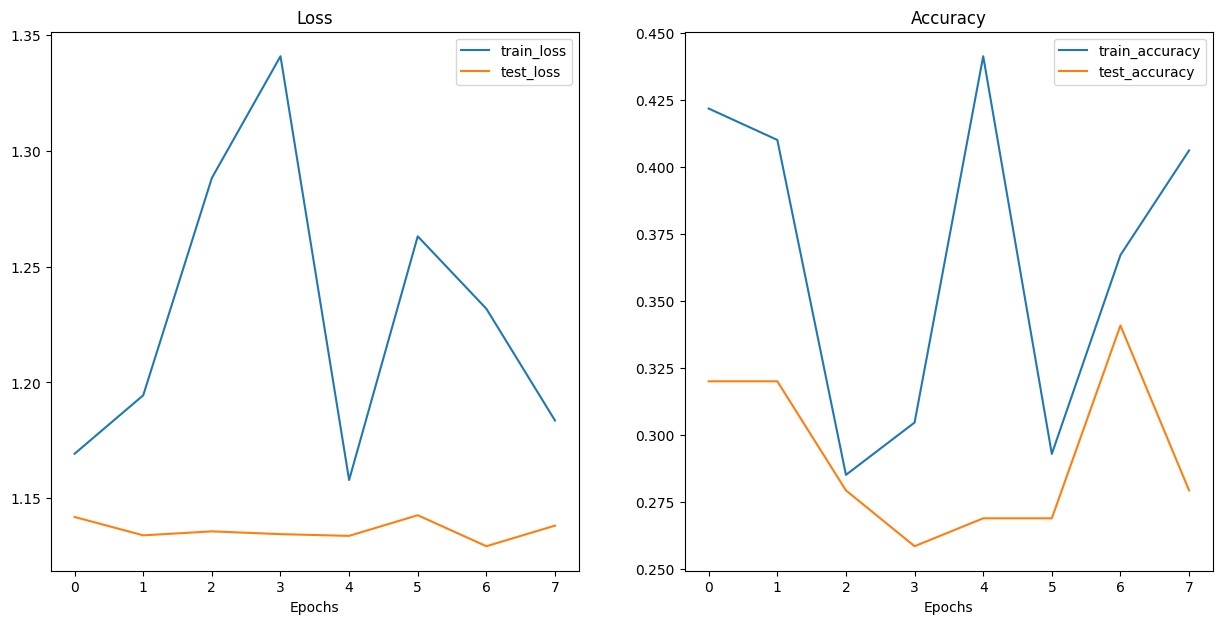

In [139]:
plot_loss_curves(model_0_result), plot_loss_curves(model_1_result)


## 7.0 Make predictions on a custom image

### 7.1 Downloading image

In [140]:
import requests 

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")

        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

In [143]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

print(f"Custom image tensor: \n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor: 
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dt

In [144]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

custom_image = custom_image / 255

print(f"Custom image tensor: \n{custom_image}\n")
print(f"Custom image shape: {custom_image.shape}\n")
print(f"Custom image dtype: {custom_image.dtype}")

Custom image tensor: 
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  .

In [147]:
custom_image_transform = v2.Compose([
    v2.Resize((64, 64))
])

custom_image_transformed = custom_image_transform(custom_image)

print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
New shape: torch.Size([3, 64, 64])


In [149]:
model_1.eval()
with torch.inference_mode():

    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)



    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")



    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


In [150]:
custom_image_pred

tensor([[0.2875, 0.4510, 0.5503]], device='cuda:0')

In [151]:
print(f"Prediction logits: {custom_image_pred}")

custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probablilities: {custom_image_pred_probs}")

custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")

Prediction logits: tensor([[0.2875, 0.4510, 0.5503]], device='cuda:0')
Prediction probablilities: tensor([[0.2875, 0.3386, 0.3739]], device='cuda:0')
Prediction label: tensor([2], device='cuda:0')


In [152]:
custom_image_pred_class = class_name[custom_image_pred_label.cpu()]
custom_image_pred_class

'sushi'

In [153]:
custom_image_pred_probs


tensor([[0.2875, 0.3386, 0.3739]], device='cuda:0')

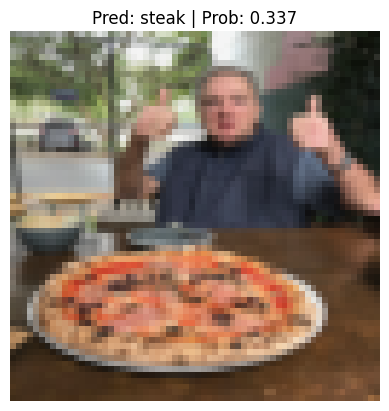

In [155]:
pred_and_plot_image(model=model_0,
                    image_path=custom_image_path,
                    class_names=class_name,
                    transform=custom_image_transform,
                    device=device)

## 8.0 Improving model

In [160]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 5

model_0_result = train(model=model_0,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_simple,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS)

 20%|██        | 1/5 [00:21<01:26, 21.57s/it]


Epoch 0
----------
Train loss: 1.1074 | Train acc: 0.2500 | Test loss: 1.1059 | Test acc: 0.2604


100%|██████████| 5/5 [01:49<00:00, 21.84s/it]


In [161]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 10

model_0_result = train(model=model_0,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_simple,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS)

 10%|█         | 1/10 [00:23<03:28, 23.13s/it]


Epoch 0
----------
Train loss: 1.1007 | Train acc: 0.4258 | Test loss: 1.1070 | Test acc: 0.2604


 60%|██████    | 6/10 [02:20<01:33, 23.43s/it]


Epoch 5
----------
Train loss: 1.0972 | Train acc: 0.3047 | Test loss: 1.1463 | Test acc: 0.2604


100%|██████████| 10/10 [03:54<00:00, 23.47s/it]


In [162]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 20

model_0_result = train(model=model_0,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_simple,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS)

  5%|▌         | 1/20 [00:22<07:11, 22.72s/it]


Epoch 0
----------
Train loss: 1.0108 | Train acc: 0.4648 | Test loss: 1.0871 | Test acc: 0.3930


 30%|███       | 6/20 [02:17<05:23, 23.11s/it]


Epoch 5
----------
Train loss: 1.0114 | Train acc: 0.4219 | Test loss: 1.1021 | Test acc: 0.3722


 55%|█████▌    | 11/20 [04:13<03:28, 23.14s/it]


Epoch 10
----------
Train loss: 0.8901 | Train acc: 0.5742 | Test loss: 1.1140 | Test acc: 0.3835


 80%|████████  | 16/20 [06:10<01:34, 23.59s/it]


Epoch 15
----------
Train loss: 0.9042 | Train acc: 0.5859 | Test loss: 1.0452 | Test acc: 0.3627


100%|██████████| 20/20 [07:42<00:00, 23.10s/it]


In [164]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                            lr=0.001)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 50

model_0_result = train(model=model_0,
      train_dataloader=train_dataloader_augmented,
      test_dataloader=test_dataloader_simple,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS)

  2%|▏         | 1/50 [00:25<20:26, 25.03s/it]


Epoch 0
----------
Train loss: 0.9073 | Train acc: 0.6172 | Test loss: 1.0172 | Test acc: 0.4233


 12%|█▏        | 6/50 [02:23<17:16, 23.57s/it]


Epoch 5
----------
Train loss: 1.0595 | Train acc: 0.5117 | Test loss: 1.0515 | Test acc: 0.4129


 22%|██▏       | 11/50 [04:19<15:03, 23.17s/it]

...


Epoch 40
----------
Train loss: 0.8676 | Train acc: 0.5430 | Test loss: 1.0281 | Test acc: 0.4659


 92%|█████████▏| 46/50 [18:07<01:35, 23.78s/it]


Epoch 45
----------
Train loss: 0.7813 | Train acc: 0.6875 | Test loss: 1.0814 | Test acc: 0.4347


100%|██████████| 50/50 [19:43<00:00, 23.67s/it]


Epoch 49
----------
Train loss: 0.8210 | Train acc: 0.5859 | Test loss: 1.0805 | Test acc: 0.4138
